In [9]:
from pathlib import Path
import json
import random

import cv2
import matplotlib.pyplot as plt
import pandas as pd

In [10]:
dataset = Path("../data/raw/OpenLogo")

for file in dataset.iterdir():
    print(file)

..\data\raw\OpenLogo\.git
..\data\raw\OpenLogo\.gitattributes
..\data\raw\OpenLogo\data
..\data\raw\OpenLogo\fiftyone.yml
..\data\raw\OpenLogo\metadata.json
..\data\raw\OpenLogo\openlogo.gif
..\data\raw\OpenLogo\README.md
..\data\raw\OpenLogo\samples.json


In [11]:
images = list(dataset.rglob("*.jpg")) + list(dataset.rglob("*.png"))

print(len(images))

27083


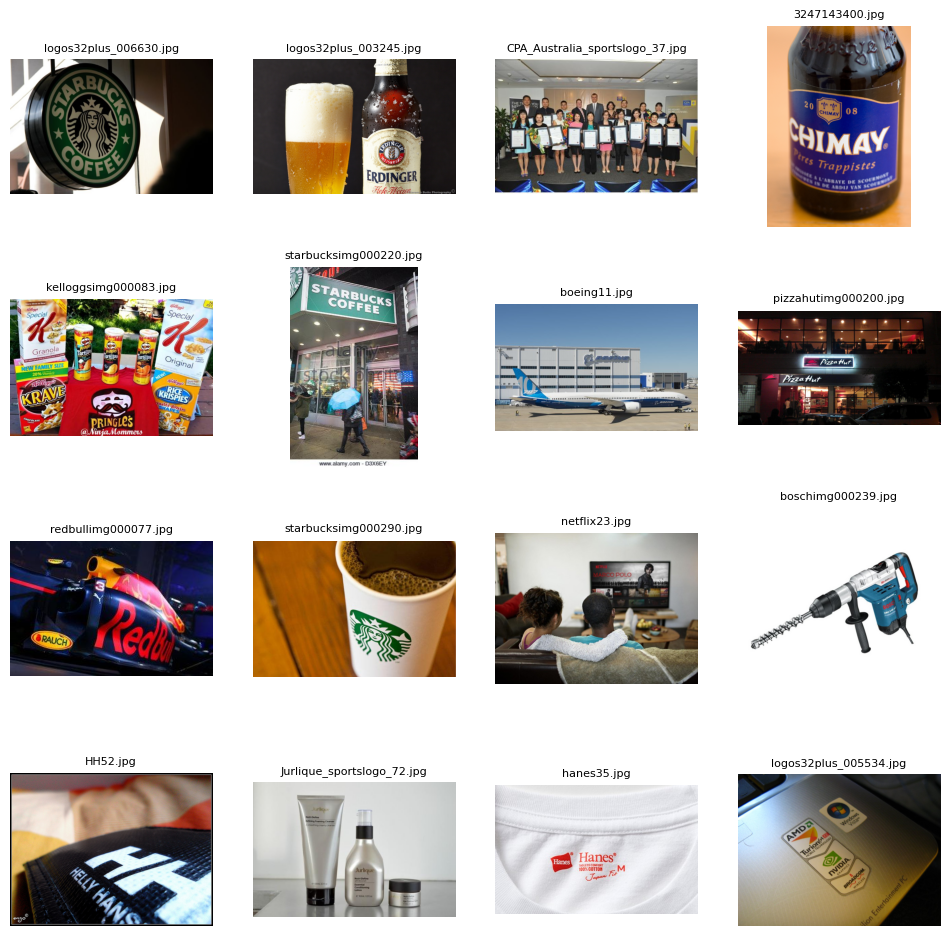

In [12]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, img_path in zip(axes.ravel(), random.sample(images, 16)):
    
    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ax.imshow(image)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')

plt.show()

In [ ]:
sizes = []

for img_path in images:
    
    image = cv2.imread(str(img_path))
    h, w = image.shape[:2]
    sizes.append([w, h])

sizes = pd.DataFrame(sizes, columns=['width', 'height'])
sizes.head()

In [ ]:
plt.figure(figsize=(6,5))

plt.scatter(sizes['width'], sizes['height'], alpha=0.4)

plt.xlabel('Width')
plt.ylabel('Height')

plt.show()

In [13]:
import pprint

samples_path = dataset / 'samples.json'

with open(samples_path, 'r', encoding='utf-8') as f:
    data = json.load(f)
    print(type(data))
    print(data.keys())
    
    sample = data['samples'][0]
    print(sample)
    print(sample.keys())

    print(len(data['samples']))

    pprint.pprint(sample)


<class 'dict'>
dict_keys(['samples'])
{'_id': {'$oid': '6a0caf791b7747aef05b1a4c'}, 'filepath': 'data/data_0/coach5.jpg', 'tags': [], '_media_type': 'image', '_rand': 0.9992033885008083, 'split': 'train', 'width': 604, 'height': 720, 'ground_truth': {'_cls': 'Detections', 'detections': [{'_id': {'$oid': '6a0caf711b7747aef05a9b1d'}, '_cls': 'Detection', 'attributes': {}, 'tags': [], 'label': 'coach', 'bounding_box': [0.44039735099337746, 0.6305555555555555, 0.09271523178807947, 0.029166666666666667], 'difficult': False, 'truncated': False}]}, 'num_logos': 1, 'logo_classes': ['coach'], '_dataset_id': {'$oid': '6a0caf6c1b7747aef059ffc6'}, 'created_at': {'$date': '2026-05-19T18:44:09.807Z'}, 'last_modified_at': {'$date': '2026-05-19T18:44:09.807Z'}}
dict_keys(['_id', 'filepath', 'tags', '_media_type', '_rand', 'split', 'width', 'height', 'ground_truth', 'num_logos', 'logo_classes', '_dataset_id', 'created_at', 'last_modified_at'])
27083
{'_dataset_id': {'$oid': '6a0caf6c1b7747aef059ffc6'},

604 720
{'_id': {'$oid': '6a0caf711b7747aef05a9b1d'}, '_cls': 'Detection', 'attributes': {}, 'tags': [], 'label': 'coach', 'bounding_box': [0.44039735099337746, 0.6305555555555555, 0.09271523178807947, 0.029166666666666667], 'difficult': False, 'truncated': False}


(np.float64(-0.5), np.float64(603.5), np.float64(719.5), np.float64(-0.5))

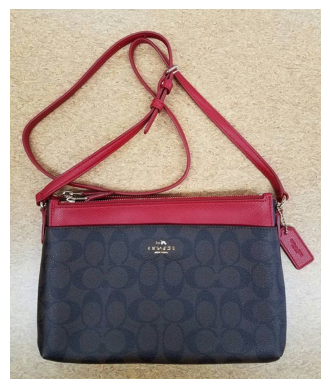

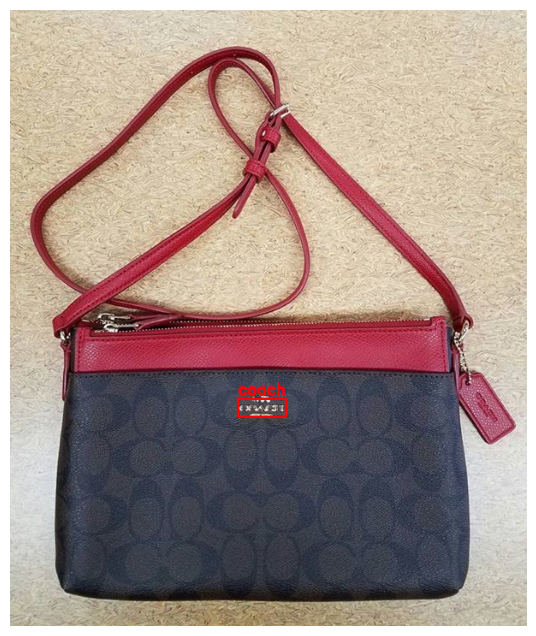

In [14]:
sample = data['samples'][0]
image_path = dataset / sample['filepath']
image = cv2.imread(str(image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis('off')

height, width = image.shape[:2]
print(width, height)

detections = sample['ground_truth']['detections']
print(detections[0])

bbox = detections[0]['bounding_box']

x = int(bbox[0] * width)
y = int(bbox[1] * height)
w = int(bbox[2] * width)
h = int(bbox[3] * height)

cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 2)

label = detections[0]['label']

cv2.putText(image, label, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis('off')
